# 📊 VISUALISASI — Choropleth, PCA Scatter, Radar, ASEAN Bar

**Tujuan:** Membuat 4 visualisasi utama untuk laporan dan infografis pameran.

| # | Chart | Library | Output |
|---|-------|---------|--------|
| 1 | Peta Choropleth Dunia | plotly | `choropleth_map.html` |
| 2 | Scatter PCA 2D + ASEAN | plotly | `scatter_pca.html` |
| 3 | Radar Chart 4 Cluster | matplotlib | `radar_chart.png` |
| 4 | Bar Chart ASEAN | matplotlib | `asean_comparison.png` |

**Prerequisite:** Jalankan `03_gold.ipynb` terlebih dahulu.

In [9]:
!pip install plotly -q

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Load hasil clustering dari Gold
df = pd.read_csv("/data/gold/clustering_result.csv")

FEATURES = ["SP.ADO.TFRT", "SH.STA.MMRT", "SG.GEN.PARL.ZS", "SL.TLF.ACTI.FE.ZS"]
ASEAN_CODES = ['IDN', 'MYS', 'SGP', 'THA', 'PHL', 'VNM', 'MMR', 'KHM', 'LAO', 'BRN', 'TLS']

# Label sesuai profil aktual
CLUSTER_LABELS = {
    0: "Progresif \u2014 Kesetaraan Terbaik",
    1: "Kritis \u2014 MMR & Fertilitas Tinggi",
    2: "Rentan \u2014 Partisipasi Perempuan Rendah",
    3: "Berkembang Stabil"
}

CLUSTER_COLORS = {
    "Progresif \u2014 Kesetaraan Terbaik": "#4575b4",
    "Kritis \u2014 MMR & Fertilitas Tinggi": "#d73027",
    "Rentan \u2014 Partisipasi Perempuan Rendah": "#fc8d59",
    "Berkembang Stabil": "#91bfdb"
}

COLORS_BY_ID = {0: "#4575b4", 1: "#d73027", 2: "#fc8d59", 3: "#91bfdb"}

# Pastikan cluster_label ada
if "cluster_label" not in df.columns:
    df["cluster_label"] = df["cluster"].map(CLUSTER_LABELS)

if "is_asean" not in df.columns:
    df["is_asean"] = df["Country Code"].isin(ASEAN_CODES)

print(f"✅ Data dimuat: {len(df)} negara, {df['is_asean'].sum()} ASEAN")
print(f"Cluster distribution:")
for c in sorted(df['cluster'].unique()):
    print(f"  Cluster {c} ({CLUSTER_LABELS[c]}): {(df['cluster']==c).sum()} negara")

✅ Data dimuat: 212 negara, 10 ASEAN
Cluster distribution:
  Cluster 0 (Progresif — Kesetaraan Terbaik): 61 negara
  Cluster 1 (Kritis — MMR & Fertilitas Tinggi): 29 negara
  Cluster 2 (Rentan — Partisipasi Perempuan Rendah): 42 negara
  Cluster 3 (Berkembang Stabil): 80 negara


In [11]:
# ============================================================
# VISUALISASI 1: CHOROPLETH MAP (Peta Dunia per Cluster)
# ============================================================
fig = px.choropleth(
    df,
    locations="Country Code",
    color="cluster_label",
    hover_name="Country Name",
    hover_data={
        "cluster_label": True,
        "Income Group": True,
        "SP.ADO.TFRT": ":.3f",
        "SH.STA.MMRT": ":.3f",
        "SG.GEN.PARL.ZS": ":.3f",
        "SL.TLF.ACTI.FE.ZS": ":.3f"
    },
    color_discrete_map=CLUSTER_COLORS,
    title="Peta Profil Kesetaraan Gender Global (SDG 5) \u2014 K-Means k=4"
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="gray",
        projection_type='natural earth',
        bgcolor='#f9f9f9'
    ),
    title_font_size=16,
    title_x=0.5,
    legend_title="Cluster",
    legend=dict(orientation="h", yanchor="bottom", y=-0.1, xanchor="center", x=0.5),
    height=600,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html("/data/gold/choropleth_map.html")
fig.show()

print("\n📸 File tersimpan: /data/gold/choropleth_map.html")
print("   Buka file ini di browser untuk tampilan interaktif!")


📸 File tersimpan: /data/gold/choropleth_map.html
   Buka file ini di browser untuk tampilan interaktif!


In [12]:
# ============================================================
# VISUALISASI 2: SCATTER PCA 2D + HIGHLIGHT ASEAN
# ============================================================
fig = go.Figure()

# Plot semua negara (non-ASEAN)
for c in sorted(CLUSTER_LABELS.keys()):
    subset = df[(df["cluster"] == c) & (~df["is_asean"])]
    fig.add_trace(go.Scatter(
        x=subset["PC1"], y=subset["PC2"],
        mode="markers",
        marker=dict(color=COLORS_BY_ID[c], size=8, opacity=0.5,
                    line=dict(color='white', width=0.5)),
        name=CLUSTER_LABELS[c],
        hovertext=subset["Country Name"],
        hoverinfo="text+x+y"
    ))

# Highlight ASEAN dengan bintang
for c in sorted(CLUSTER_LABELS.keys()):
    subset = df[(df["cluster"] == c) & (df["is_asean"])]
    if len(subset) > 0:
        fig.add_trace(go.Scatter(
            x=subset["PC1"], y=subset["PC2"],
            mode="markers+text",
            marker=dict(
                color=COLORS_BY_ID[c], size=16, symbol="star",
                line=dict(color="black", width=2)
            ),
            text=subset["Country Name"],
            textposition="top center",
            textfont=dict(size=10, color="black"),
            name=f"ASEAN \u2014 {CLUSTER_LABELS[c]}",
            hovertext=subset["Country Name"],
            hoverinfo="text+x+y"
        ))

fig.update_layout(
    title=dict(
        text="Scatter PCA 2D \u2014 217 Negara, \u2b50 = ASEAN",
        font_size=16, x=0.5
    ),
    xaxis_title="PC1",
    yaxis_title="PC2",
    height=650,
    showlegend=True,
    legend=dict(font_size=10),
    plot_bgcolor='#fafafa'
)

fig.write_html("/data/gold/scatter_pca.html")
fig.show()

print("\n📸 File tersimpan: /data/gold/scatter_pca.html")


📸 File tersimpan: /data/gold/scatter_pca.html


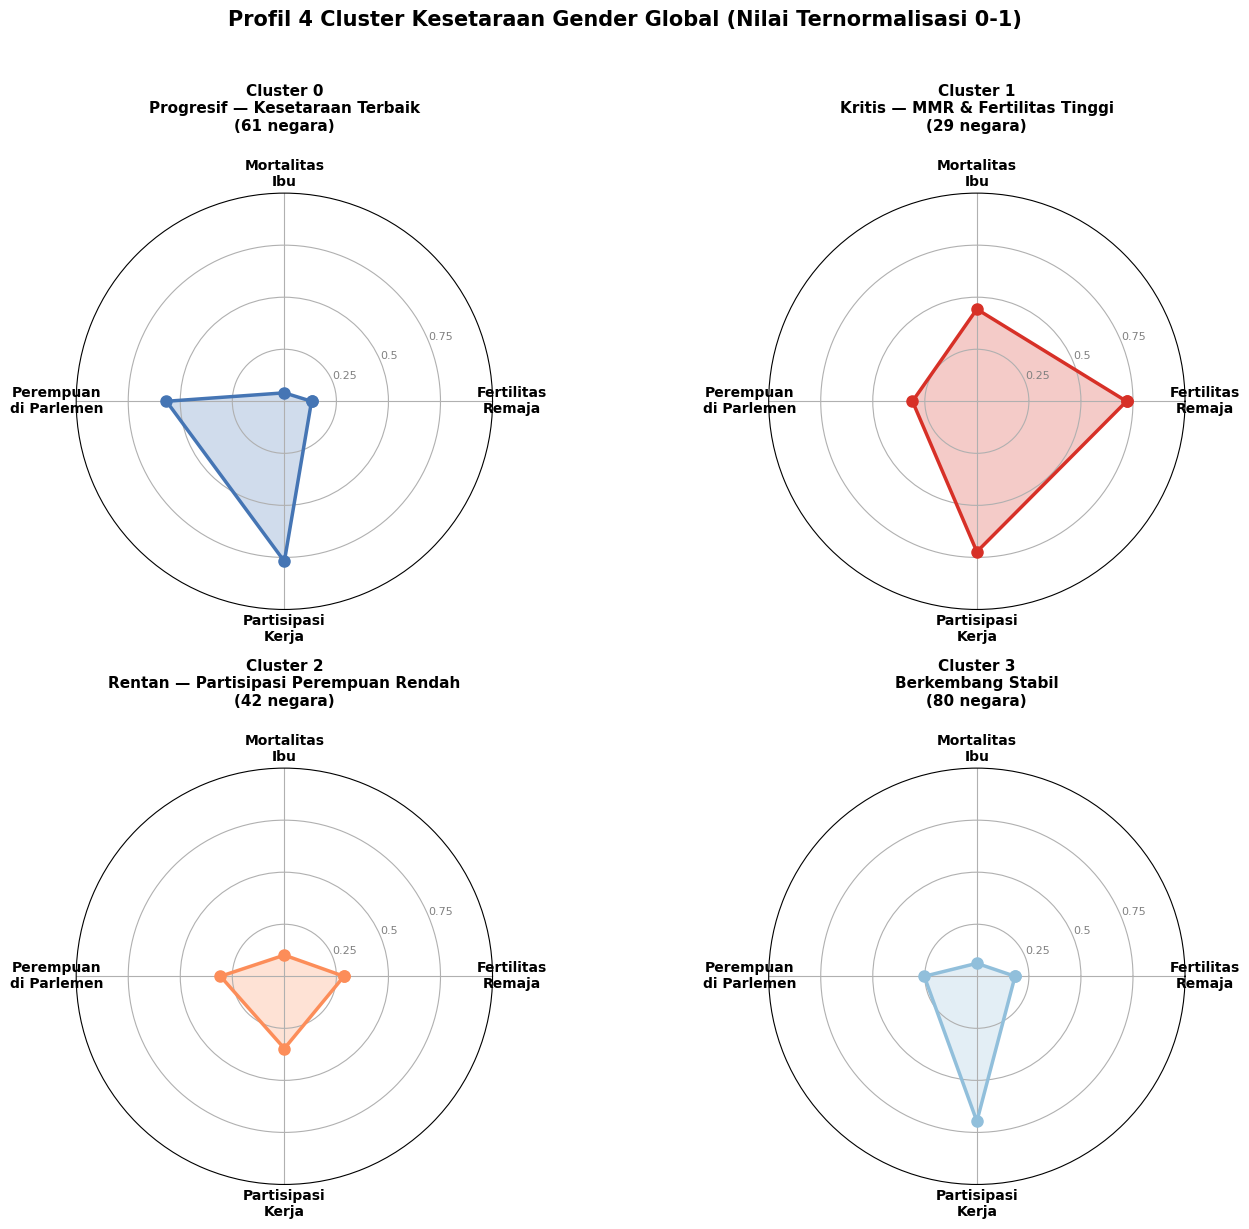


📸 File tersimpan: /data/gold/radar_chart.png


In [13]:
# ============================================================
# VISUALISASI 3: RADAR CHART PROFIL 4 CLUSTER
# ============================================================
# Hitung profil cluster (nilai ternormalisasi 0-1)
cluster_profile = df.groupby("cluster")[FEATURES].mean()

feature_short = [
    "Fertilitas\nRemaja",
    "Mortalitas\nIbu",
    "Perempuan\ndi Parlemen",
    "Partisipasi\nKerja"
]

angles = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False).tolist()
angles += angles[:1]  # tutup polygon

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()
# Warna sesuai COLORS_BY_ID: 0=Progresif(biru), 1=Kritis(merah), 2=Rentan(oranye), 3=Berkembang(biru muda)
colors_radar = [COLORS_BY_ID[i] for i in range(4)]

for i, (ax, color) in enumerate(zip(axes, colors_radar)):
    values = cluster_profile.iloc[i].tolist()
    values += values[:1]  # tutup polygon

    ax.plot(angles, values, 'o-', color=color, linewidth=2.5, markersize=8)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_short, size=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.5", "0.75"], size=8, color='gray')

    count = (df["cluster"] == i).sum()
    ax.set_title(
        f"Cluster {i}\n{CLUSTER_LABELS[i]}\n({count} negara)",
        fontsize=11, fontweight='bold', pad=20
    )

plt.suptitle(
    "Profil 4 Cluster Kesetaraan Gender Global (Nilai Ternormalisasi 0-1)",
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("/data/gold/radar_chart.png", dpi=200, bbox_inches='tight')
plt.show()

print("\n📸 File tersimpan: /data/gold/radar_chart.png")

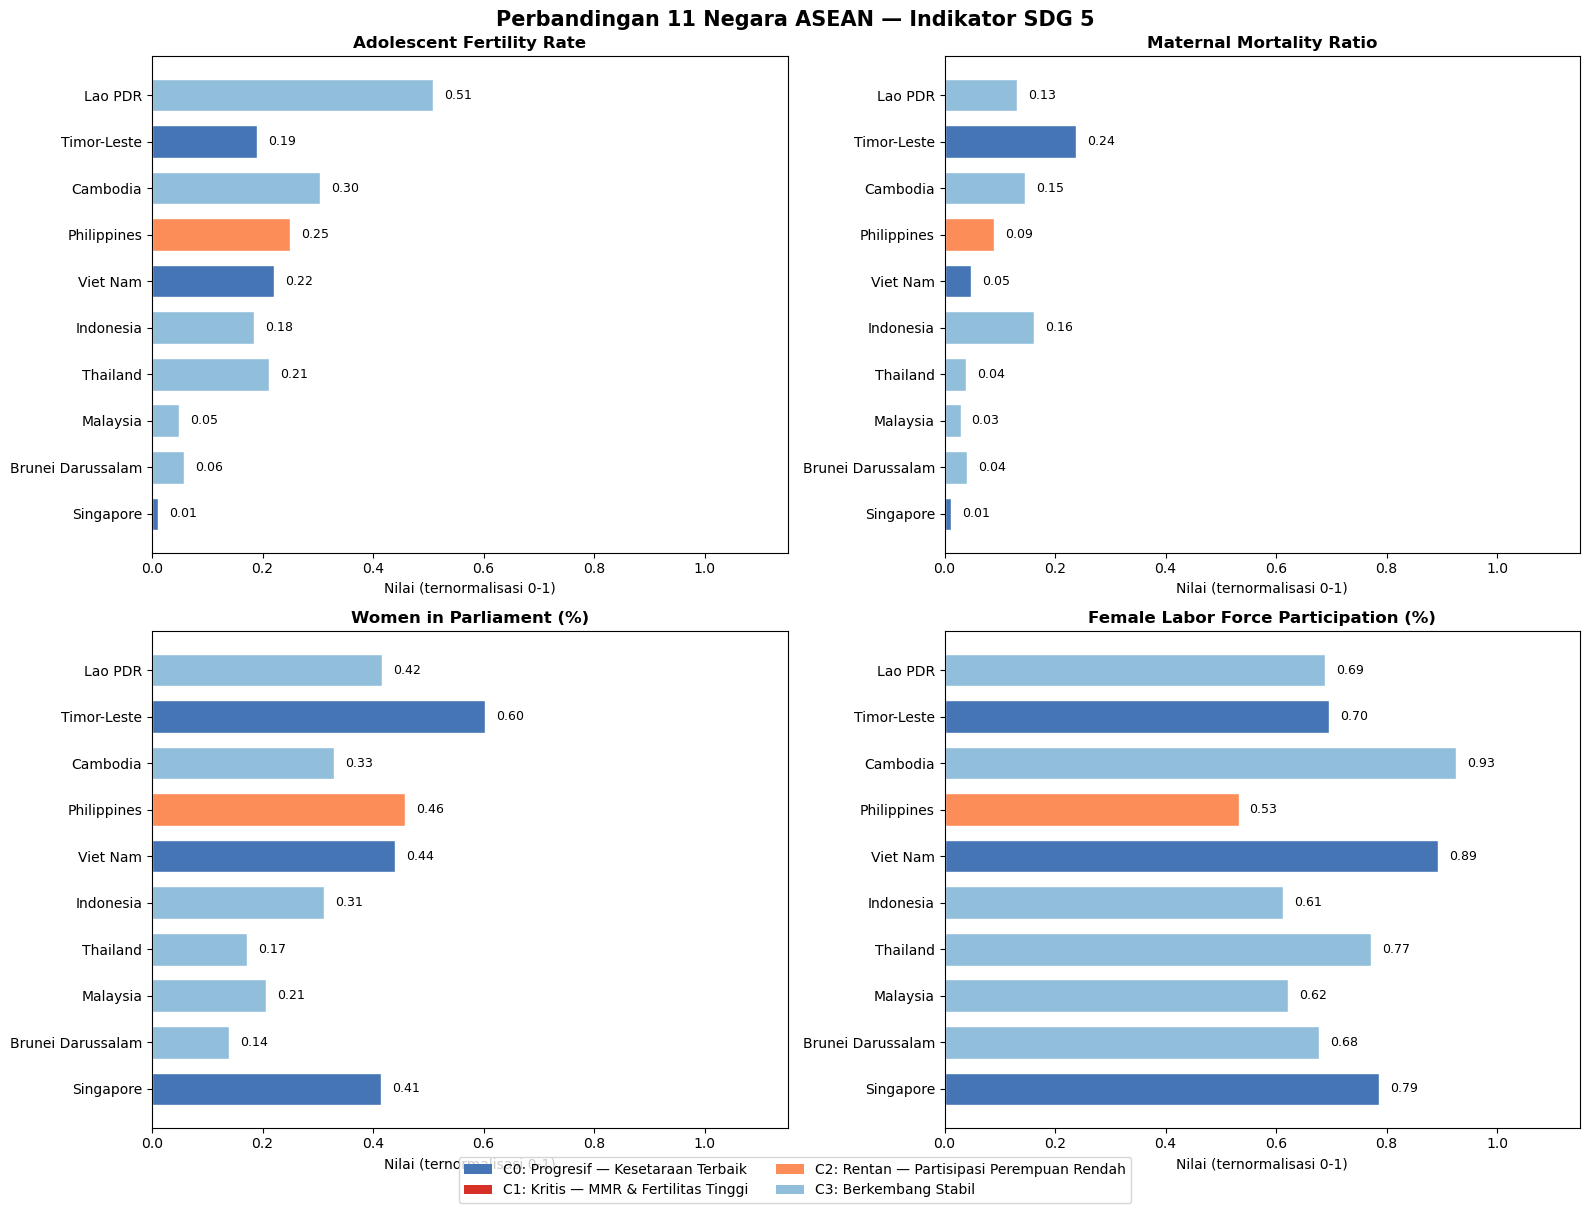


📸 File tersimpan: /data/gold/asean_comparison.png


In [14]:
# ============================================================
# VISUALISASI 4: BAR CHART PERBANDINGAN ASEAN
# ============================================================
asean_order = ['SGP', 'BRN', 'MYS', 'THA', 'IDN', 'VNM', 'PHL', 'KHM', 'MMR', 'TLS', 'LAO']

df_asean = df[df["Country Code"].isin(asean_order)].copy()
df_asean["sort_order"] = df_asean["Country Code"].apply(lambda x: asean_order.index(x))
df_asean = df_asean.sort_values("sort_order")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

feature_names = [
    "Adolescent Fertility Rate\n(rendah = lebih baik)",
    "Maternal Mortality Ratio\n(rendah = lebih baik)",
    "Women in Parliament (%)\n(tinggi = lebih baik)",
    "Female Labor Force Participation (%)\n(tinggi = lebih baik)"
]

asean_colors = df_asean["cluster"].map(COLORS_BY_ID).tolist()

for ax, feat, fname in zip(axes, FEATURES, feature_names):
    bars = ax.barh(
        df_asean["Country Name"], df_asean[feat],
        color=asean_colors, edgecolor="white", height=0.7
    )
    ax.set_xlabel("Nilai (ternormalisasi 0-1)", fontsize=10)
    ax.set_title(fname.split("\n")[0], fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.set_xlim(0, 1.15)

    for bar, val in zip(bars, df_asean[feat]):
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center', fontsize=9
        )

# Legend manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS_BY_ID[i], label=f"C{i}: {CLUSTER_LABELS[i]}")
    for i in sorted(CLUSTER_LABELS.keys())
]
fig.legend(
    handles=legend_elements, loc='lower center',
    ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02)
)

plt.suptitle(
    "Perbandingan 11 Negara ASEAN \u2014 Indikator SDG 5",
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig("/data/gold/asean_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

print("\n📸 File tersimpan: /data/gold/asean_comparison.png")

In [15]:
# ============================================================
# RINGKASAN SEMUA OUTPUT
# ============================================================
import os

print("=" * 60)
print("  ✅ SEMUA VISUALISASI SELESAI!")
print("=" * 60)

output_files = [
    ("/data/gold/choropleth_map.html", "Peta Choropleth Dunia (interaktif)"),
    ("/data/gold/scatter_pca.html", "Scatter PCA 2D + ASEAN (interaktif)"),
    ("/data/gold/radar_chart.png", "Radar Chart 4 Cluster"),
    ("/data/gold/asean_comparison.png", "Bar Chart Perbandingan ASEAN"),
    ("/data/gold/elbow_chart.png", "Elbow Method Chart"),
    ("/data/gold/silhouette_chart.png", "Silhouette Score Chart"),
    ("/data/gold/clustering_result.csv", "Data Clustering (CSV)"),
    ("/data/gold/clustering_result.parquet", "Data Clustering (Parquet)")
]

print("\nFile yang dihasilkan:")
for filepath, desc in output_files:
    exists = os.path.exists(filepath)
    status = "✅" if exists else "❌"
    if exists:
        size = os.path.getsize(filepath)
        if size > 1024 * 1024:
            size_str = f"{size / 1024 / 1024:.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {status} {filepath} ({size_str}) — {desc}")
    else:
        print(f"  {status} {filepath} — {desc}")

print("\n" + "=" * 60)
print("  UNTUK PAMERAN:")
print("  1. Buka choropleth_map.html di browser (interaktif)")
print("  2. Buka scatter_pca.html di browser (interaktif)")
print("  3. Gunakan radar_chart.png untuk poster")
print("  4. Gunakan asean_comparison.png untuk poster")
print("  5. Tampilkan Spark UI (localhost:8080) secara live")
print("=" * 60)

  ✅ SEMUA VISUALISASI SELESAI!

File yang dihasilkan:
  ✅ /data/gold/choropleth_map.html (4.7 MB) — Peta Choropleth Dunia (interaktif)
  ✅ /data/gold/scatter_pca.html (4.6 MB) — Scatter PCA 2D + ASEAN (interaktif)
  ✅ /data/gold/radar_chart.png (394.5 KB) — Radar Chart 4 Cluster
  ✅ /data/gold/asean_comparison.png (253.7 KB) — Bar Chart Perbandingan ASEAN
  ✅ /data/gold/elbow_chart.png (65.8 KB) — Elbow Method Chart
  ✅ /data/gold/silhouette_chart.png (59.7 KB) — Silhouette Score Chart
  ✅ /data/gold/clustering_result.csv (43.1 KB) — Data Clustering (CSV)
  ✅ /data/gold/clustering_result.parquet (512 B) — Data Clustering (Parquet)

  UNTUK PAMERAN:
  1. Buka choropleth_map.html di browser (interaktif)
  2. Buka scatter_pca.html di browser (interaktif)
  3. Gunakan radar_chart.png untuk poster
  4. Gunakan asean_comparison.png untuk poster
  5. Tampilkan Spark UI (localhost:8080) secara live
